#Imports

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

In [2]:
!git clone https://github.com/OPIM5512-JSB21017/myscrapers-jsb21017.git
%cd myscrapers-jsb21017

fatal: destination path 'myscrapers-jsb21017' already exists and is not an empty directory.


/home/runner/work/myscrapers-jsb21017/myscrapers-jsb21017/notebooks/myscrapers-jsb21017


#Load Metrics History

In [3]:
# This file was created in the modeling notebook.
# It tracks how model performance changes each time you rerun training.

history_path = "artifacts/history/model_metrics_history.csv"

history = pd.read_csv(history_path)
history["run_ts"] = pd.to_datetime(history["run_ts"], errors="coerce")
history = history.sort_values("run_ts").reset_index(drop=True)

print("History shape:", history.shape)
history

History shape: (4, 9)


,run_ts,n_rows,train_valid_rows,test_rows,mae,rmse,mape,bias,best_params
0,2026-04-04 14:43:34.959503,464,394,70,5613.042967,14678.357950,0.452199,-3624.109393,"{'model__max_depth': None, 'model__min_samples..."
1,2026-04-04 17:41:05.174781,481,408,73,4363.087866,8569.449521,0.724027,-1335.177808,"{'model__max_depth': 18, 'model__min_samples_l..."
2,2026-04-04 19:02:58.290170,486,413,73,3352.644165,9396.927712,0.304545,-1852.224773,"{'model__max_depth': 18, 'model__min_samples_l..."
3,2026-04-04 19:41:06.753366,492,418,74,4150.911545,11106.314097,0.300614,-2764.026135,"{'model__max_depth': 18, 'model__min_samples_l..."


#Model Accuracy Over Time

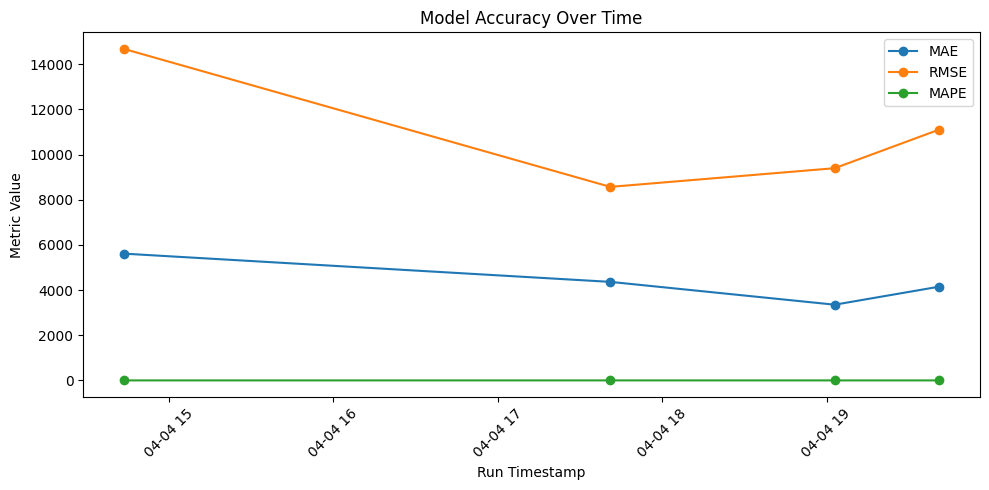

In [4]:
# This shows how your error metrics change as the dataset grows.

plt.figure(figsize=(10, 5))
plt.plot(history["run_ts"], history["mae"], marker="o", label="MAE")
plt.plot(history["run_ts"], history["rmse"], marker="o", label="RMSE")
plt.plot(history["run_ts"], history["mape"], marker="o", label="MAPE")
plt.legend()
plt.title("Model Accuracy Over Time")
plt.xlabel("Run Timestamp")
plt.ylabel("Metric Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#Bias Over Time

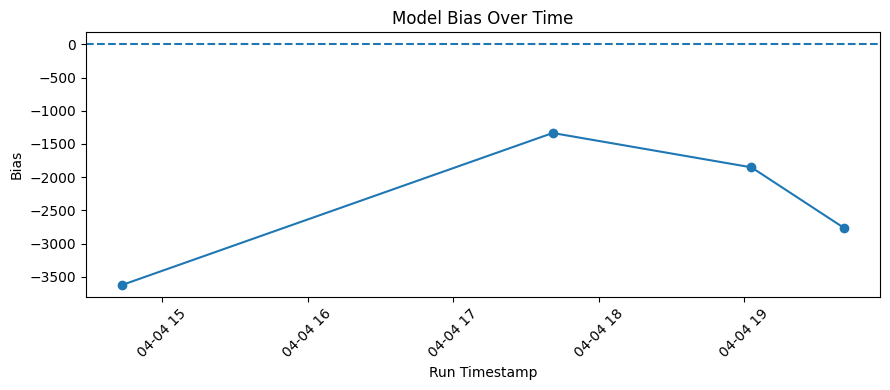

In [5]:
# Bias tells you whether the model tends to overpredict or underpredict.

plt.figure(figsize=(9, 4))
plt.plot(history["run_ts"], history["bias"], marker="o")
plt.axhline(0, linestyle="--")
plt.title("Model Bias Over Time")
plt.xlabel("Run Timestamp")
plt.ylabel("Bias")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#Dataset Growth Over Time

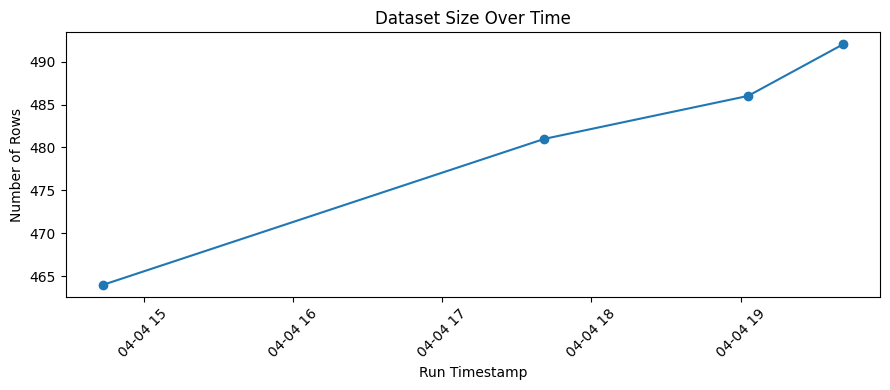

In [6]:
# This shows how the size of the modeling dataset changes.

plt.figure(figsize=(9, 4))
plt.plot(history["run_ts"], history["n_rows"], marker="o")
plt.title("Dataset Size Over Time")
plt.xlabel("Run Timestamp")
plt.ylabel("Number of Rows")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#Latest Run Summary

In [7]:
latest_run = history.iloc[-1:].copy()
latest_run

,run_ts,n_rows,train_valid_rows,test_rows,mae,rmse,mape,bias,best_params
3,2026-04-04 19:41:06.753366,492,418,74,4150.911545,11106.314097,0.300614,-2764.026135,"{'model__max_depth': 18, 'model__min_samples_l..."


#Load Permutation Importance

In [8]:
importance_path = "artifacts/importance/permutation_importance.csv"

importance = pd.read_csv(importance_path)
importance.head(15)

,feature,importance_mean,importance_std
0,num__mileage,0.364621,0.072501
1,num__year,0.147845,0.054351
2,cat__body_type_sedan,0.089418,0.019817
3,num__mileage_per_year,0.075061,0.012117
4,cat__color_unknown,0.064256,0.026230
5,num__vehicle_age,0.059407,0.031783
6,cat__seller_type_private,0.041095,0.012110
7,cat__body_type_truck,0.037325,0.009792
8,cat__body_type_wagon,0.033349,0.008097
9,cat__seller_type_dealer,0.027186,0.010326


#Plot Top Importance Features

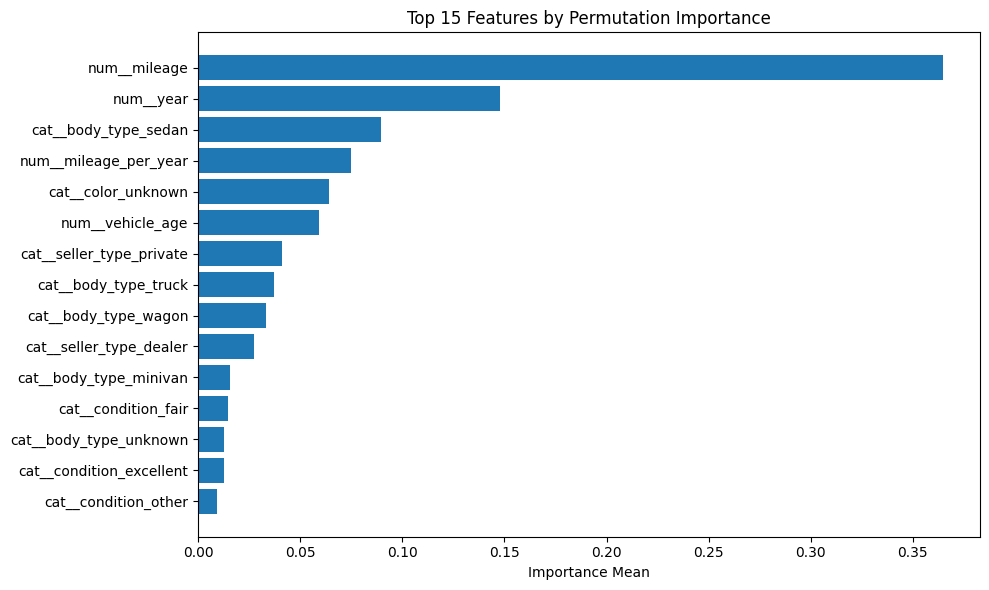

In [9]:
top15 = importance.head(15).sort_values("importance_mean")

plt.figure(figsize=(10, 6))
plt.barh(top15["feature"], top15["importance_mean"])
plt.title("Top 15 Features by Permutation Importance")
plt.xlabel("Importance Mean")
plt.tight_layout()
plt.show()

#Display PDPs

Showing: artifacts/pdp/pdp_mileage.png


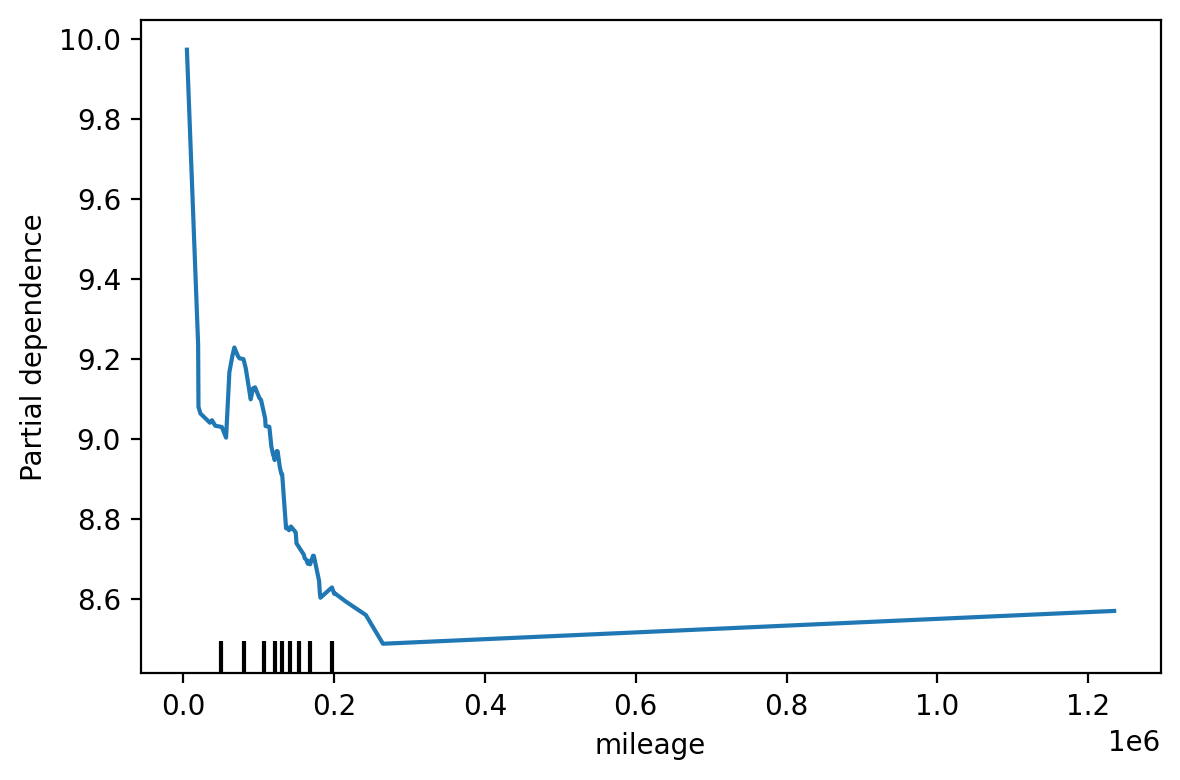

Showing: artifacts/pdp/pdp_vehicle_age.png


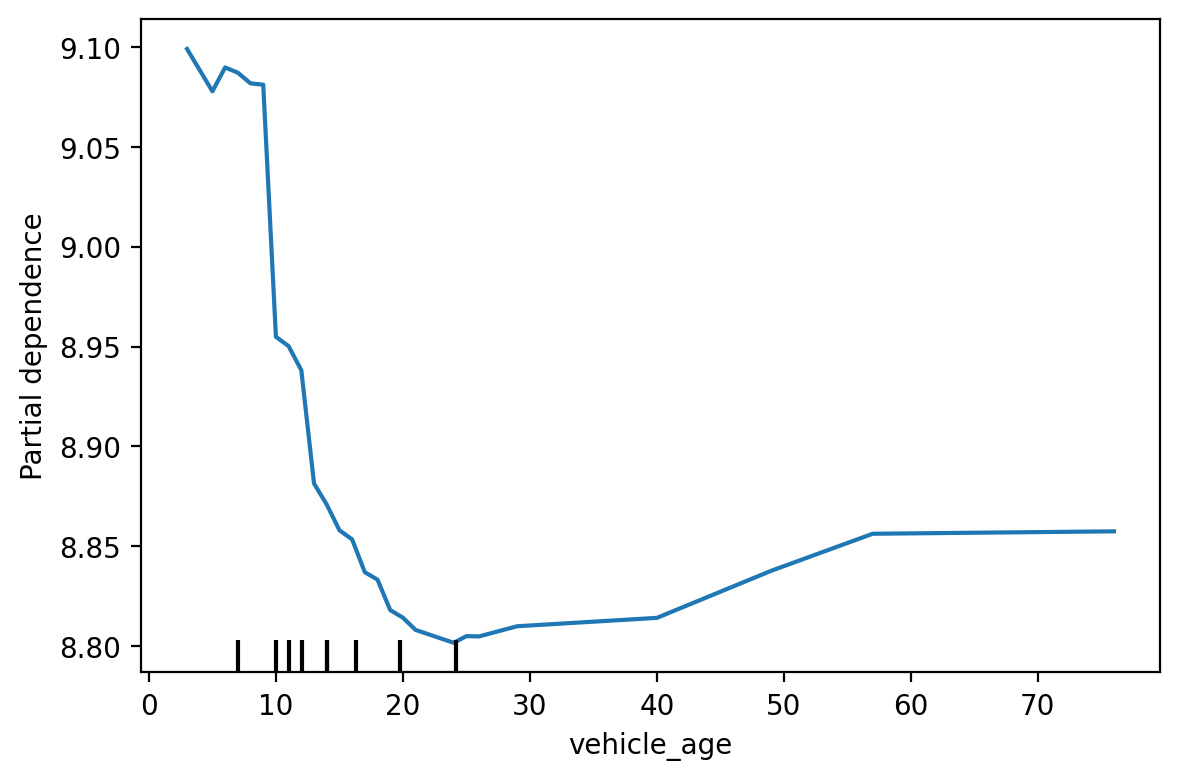

Showing: artifacts/pdp/pdp_year.png


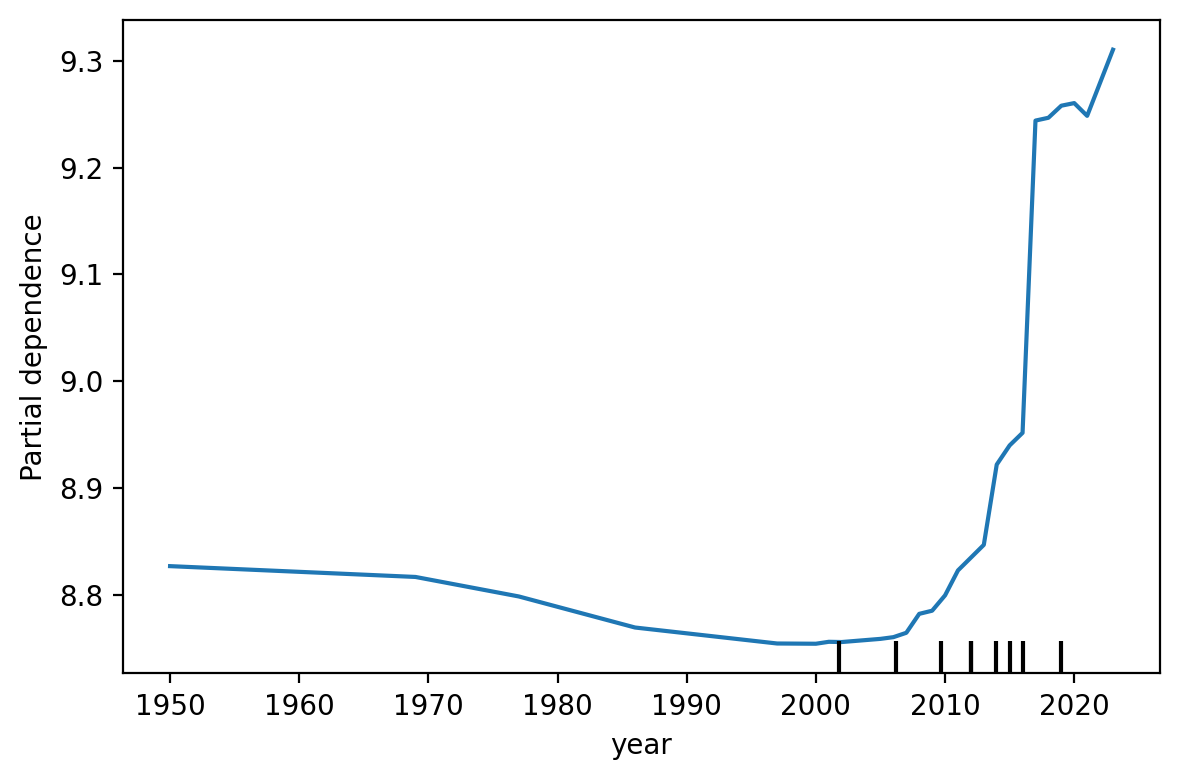

In [10]:
pdp_files = [
    "artifacts/pdp/pdp_mileage.png",
    "artifacts/pdp/pdp_vehicle_age.png",
    "artifacts/pdp/pdp_year.png",
]

for path in pdp_files:
    print("Showing:", path)
    display(Image(filename=path))

#Dashboard Summary

In [11]:
# This gives a quick readout of the latest model state.

latest = history.iloc[-1]

print("Latest Dashboard Summary:")
print(f"Rows used: {latest['n_rows']}")
print(f"MAE: {latest['mae']:.2f}")
print(f"RMSE: {latest['rmse']:.2f}")
print(f"MAPE: {latest['mape']:.4f}")
print(f"Bias: {latest['bias']:.2f}")
print()
print("Interpretation ideas:")
print("- Lower MAE/RMSE over time would suggest the model is improving as more data is added.")
print("- Bias near zero suggests the model is not strongly overpricing or underpricing on average.")
print("- Permutation importance shows which inputs matter most for price prediction.")
print("- PDPs show how the model responds to changes in major features like mileage, vehicle age, and year.")

Latest Dashboard Summary:
Rows used: 492
MAE: 4150.91
RMSE: 11106.31
MAPE: 0.3006
Bias: -2764.03

Interpretation ideas:
- Lower MAE/RMSE over time would suggest the model is improving as more data is added.
- Bias near zero suggests the model is not strongly overpricing or underpricing on average.
- Permutation importance shows which inputs matter most for price prediction.
- PDPs show how the model responds to changes in major features like mileage, vehicle age, and year.
